In [92]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn import metrics
#from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [93]:
# You can access from https://www.kaggle.com/uciml/german-credit
# Read input file and understand the data
# "default" is my dependent variable

In [94]:
credit_df = pd.read_csv("german_credit.csv")
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [95]:
credit_df.head().T

,0,1,2,3,4
default,0,1,0,0,1
account_check_status,< 0 DM,0 <= ... < 200 DM,no checking account,< 0 DM,< 0 DM
duration_in_month,6,48,12,42,24
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now,critical account/ other credits existing (not ...,existing credits paid back duly till now,delay in paying off in the past
purpose,domestic appliances,domestic appliances,(vacation - does not exist?),radio/television,car (new)
credit_amount,1169,5951,2096,7882,4870
savings,unknown/ no savings account,... < 100 DM,... < 100 DM,... < 100 DM,... < 100 DM
present_emp_since,.. >= 7 years,1 <= ... < 4 years,4 <= ... < 7 years,4 <= ... < 7 years,1 <= ... < 4 years
installment_as_income_perc,4,2,2,2,3
personal_status_sex,male : single,female : divorced/separated/married,male : single,male : single,male : single


### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [96]:
n_frac = 0.5 # 50% of the data 
seed = 7  # Random numbmer seeding for reapeatability of the code
sample_credit_df = credit_df.sample(frac=n_frac, random_state=seed)  # Sampling without replacement 

In [97]:
sample_credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 778 to 565
Data columns (total 21 columns):
default                       500 non-null int64
account_check_status          500 non-null object
duration_in_month             500 non-null int64
credit_history                500 non-null object
purpose                       500 non-null object
credit_amount                 500 non-null int64
savings                       500 non-null object
present_emp_since             500 non-null object
installment_as_income_perc    500 non-null int64
personal_status_sex           500 non-null object
other_debtors                 500 non-null object
present_res_since             500 non-null int64
property                      500 non-null object
age                           500 non-null int64
other_installment_plans       500 non-null object
housing                       500 non-null object
credits_this_bank             500 non-null int64
job                           500 non-null object


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [98]:
data_df = pd.get_dummies(sample_credit_df, drop_first=True)

In [99]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 778 to 565
Data columns (total 49 columns):
default                                                                       500 non-null int64
duration_in_month                                                             500 non-null int64
credit_amount                                                                 500 non-null int64
installment_as_income_perc                                                    500 non-null int64
present_res_since                                                             500 non-null int64
age                                                                           500 non-null int64
credits_this_bank                                                             500 non-null int64
people_under_maintenance                                                      500 non-null int64
account_check_status_< 0 DM                                                   500 non-null uint8
account_check_status

In [100]:
data_df.head().T

,778,334,271,802,216
default,0,1,0,0,0
duration_in_month,36,24,12,20,18
credit_amount,5711,4110,1402,4272,3104
installment_as_income_perc,4,3,3,1,3
present_res_since,2,4,4,4,1
age,38,23,37,24,31
credits_this_bank,2,2,1,2,1
people_under_maintenance,1,2,1,1,1
account_check_status_< 0 DM,0,1,0,1,1
account_check_status_>= 200 DM / salary assignments for at least 1 year,0,0,0,0,0


### Check for highly correlated variables but don't required any treatment for this use case

In [101]:
corr_data = data_df.corr()
corr_data

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,...,property_unknown / no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",foreign_worker_yes
default,1.000000,0.166057,0.078210,0.091136,0.049901,-0.102823,-0.027889,-0.000255,0.270616,-0.075081,...,0.114203,-0.096007,5.787566e-02,-0.107350,0.071424,-0.028326,0.014181,-0.028768,-0.040494,0.110454
duration_in_month,0.166057,1.000000,0.571134,0.088545,0.053182,-0.058248,0.014765,0.007922,0.068118,-0.084225,...,0.175016,-0.005270,4.308765e-02,-0.070029,-0.062078,0.057386,-0.093514,-0.208550,0.181978,0.153166
credit_amount,0.078210,0.571134,1.000000,-0.293294,0.092275,0.013946,0.056848,0.046434,0.019046,-0.103057,...,0.181716,-0.012211,1.125429e-02,-0.116525,-0.001075,-0.076027,0.002557,-0.184368,0.268010,0.094845
installment_as_income_perc,0.091136,0.088545,-0.293294,1.000000,0.052023,0.113460,0.030759,-0.077695,0.026364,-0.070624,...,0.055805,-0.013780,6.611968e-02,0.077246,-0.138569,0.037930,-0.143020,-0.052808,0.056380,0.081372
present_res_since,0.049901,0.053182,0.092275,0.052023,1.000000,0.232294,0.095587,0.020698,0.076353,-0.112344,...,0.172770,0.065233,-6.809125e-02,-0.342476,0.244399,0.068837,-0.035774,-0.029314,0.042434,0.079682
age,-0.102823,-0.058248,0.013946,0.113460,0.232294,1.000000,0.156110,0.118394,-0.021285,0.021312,...,0.179720,-0.023720,-4.835912e-03,0.011722,-0.191669,-0.072733,0.017852,0.027295,0.138857,0.019395
credits_this_bank,-0.027889,0.014765,0.056848,0.030759,0.095587,0.156110,1.000000,0.133200,-0.048413,0.020302,...,-0.060154,-0.037846,-9.552542e-03,0.039584,-0.017280,-0.011212,0.057000,0.031229,0.090416,-0.001661
people_under_maintenance,-0.000255,0.007922,0.046434,-0.077695,0.020698,0.118394,0.133200,1.000000,0.036794,0.012246,...,0.053943,-0.081365,1.322330e-02,-0.023520,-0.048348,-0.108639,0.032082,0.158507,-0.036913,-0.059194
account_check_status_< 0 DM,0.270616,0.068118,0.019046,0.026364,0.076353,-0.021285,-0.048413,0.036794,1.000000,-0.154997,...,0.066549,0.022690,-3.138137e-02,-0.126562,0.088760,0.000944,-0.045956,0.011399,-0.021017,-0.057737
account_check_status_>= 200 DM / salary assignments for at least 1 year,-0.075081,-0.084225,-0.103057,-0.070624,-0.112344,0.021312,0.020302,0.012246,-0.154997,1.000000,...,-0.042426,-0.017759,5.249081e-02,0.069035,-0.076906,-0.019633,0.087523,-0.008172,0.002267,-0.067461


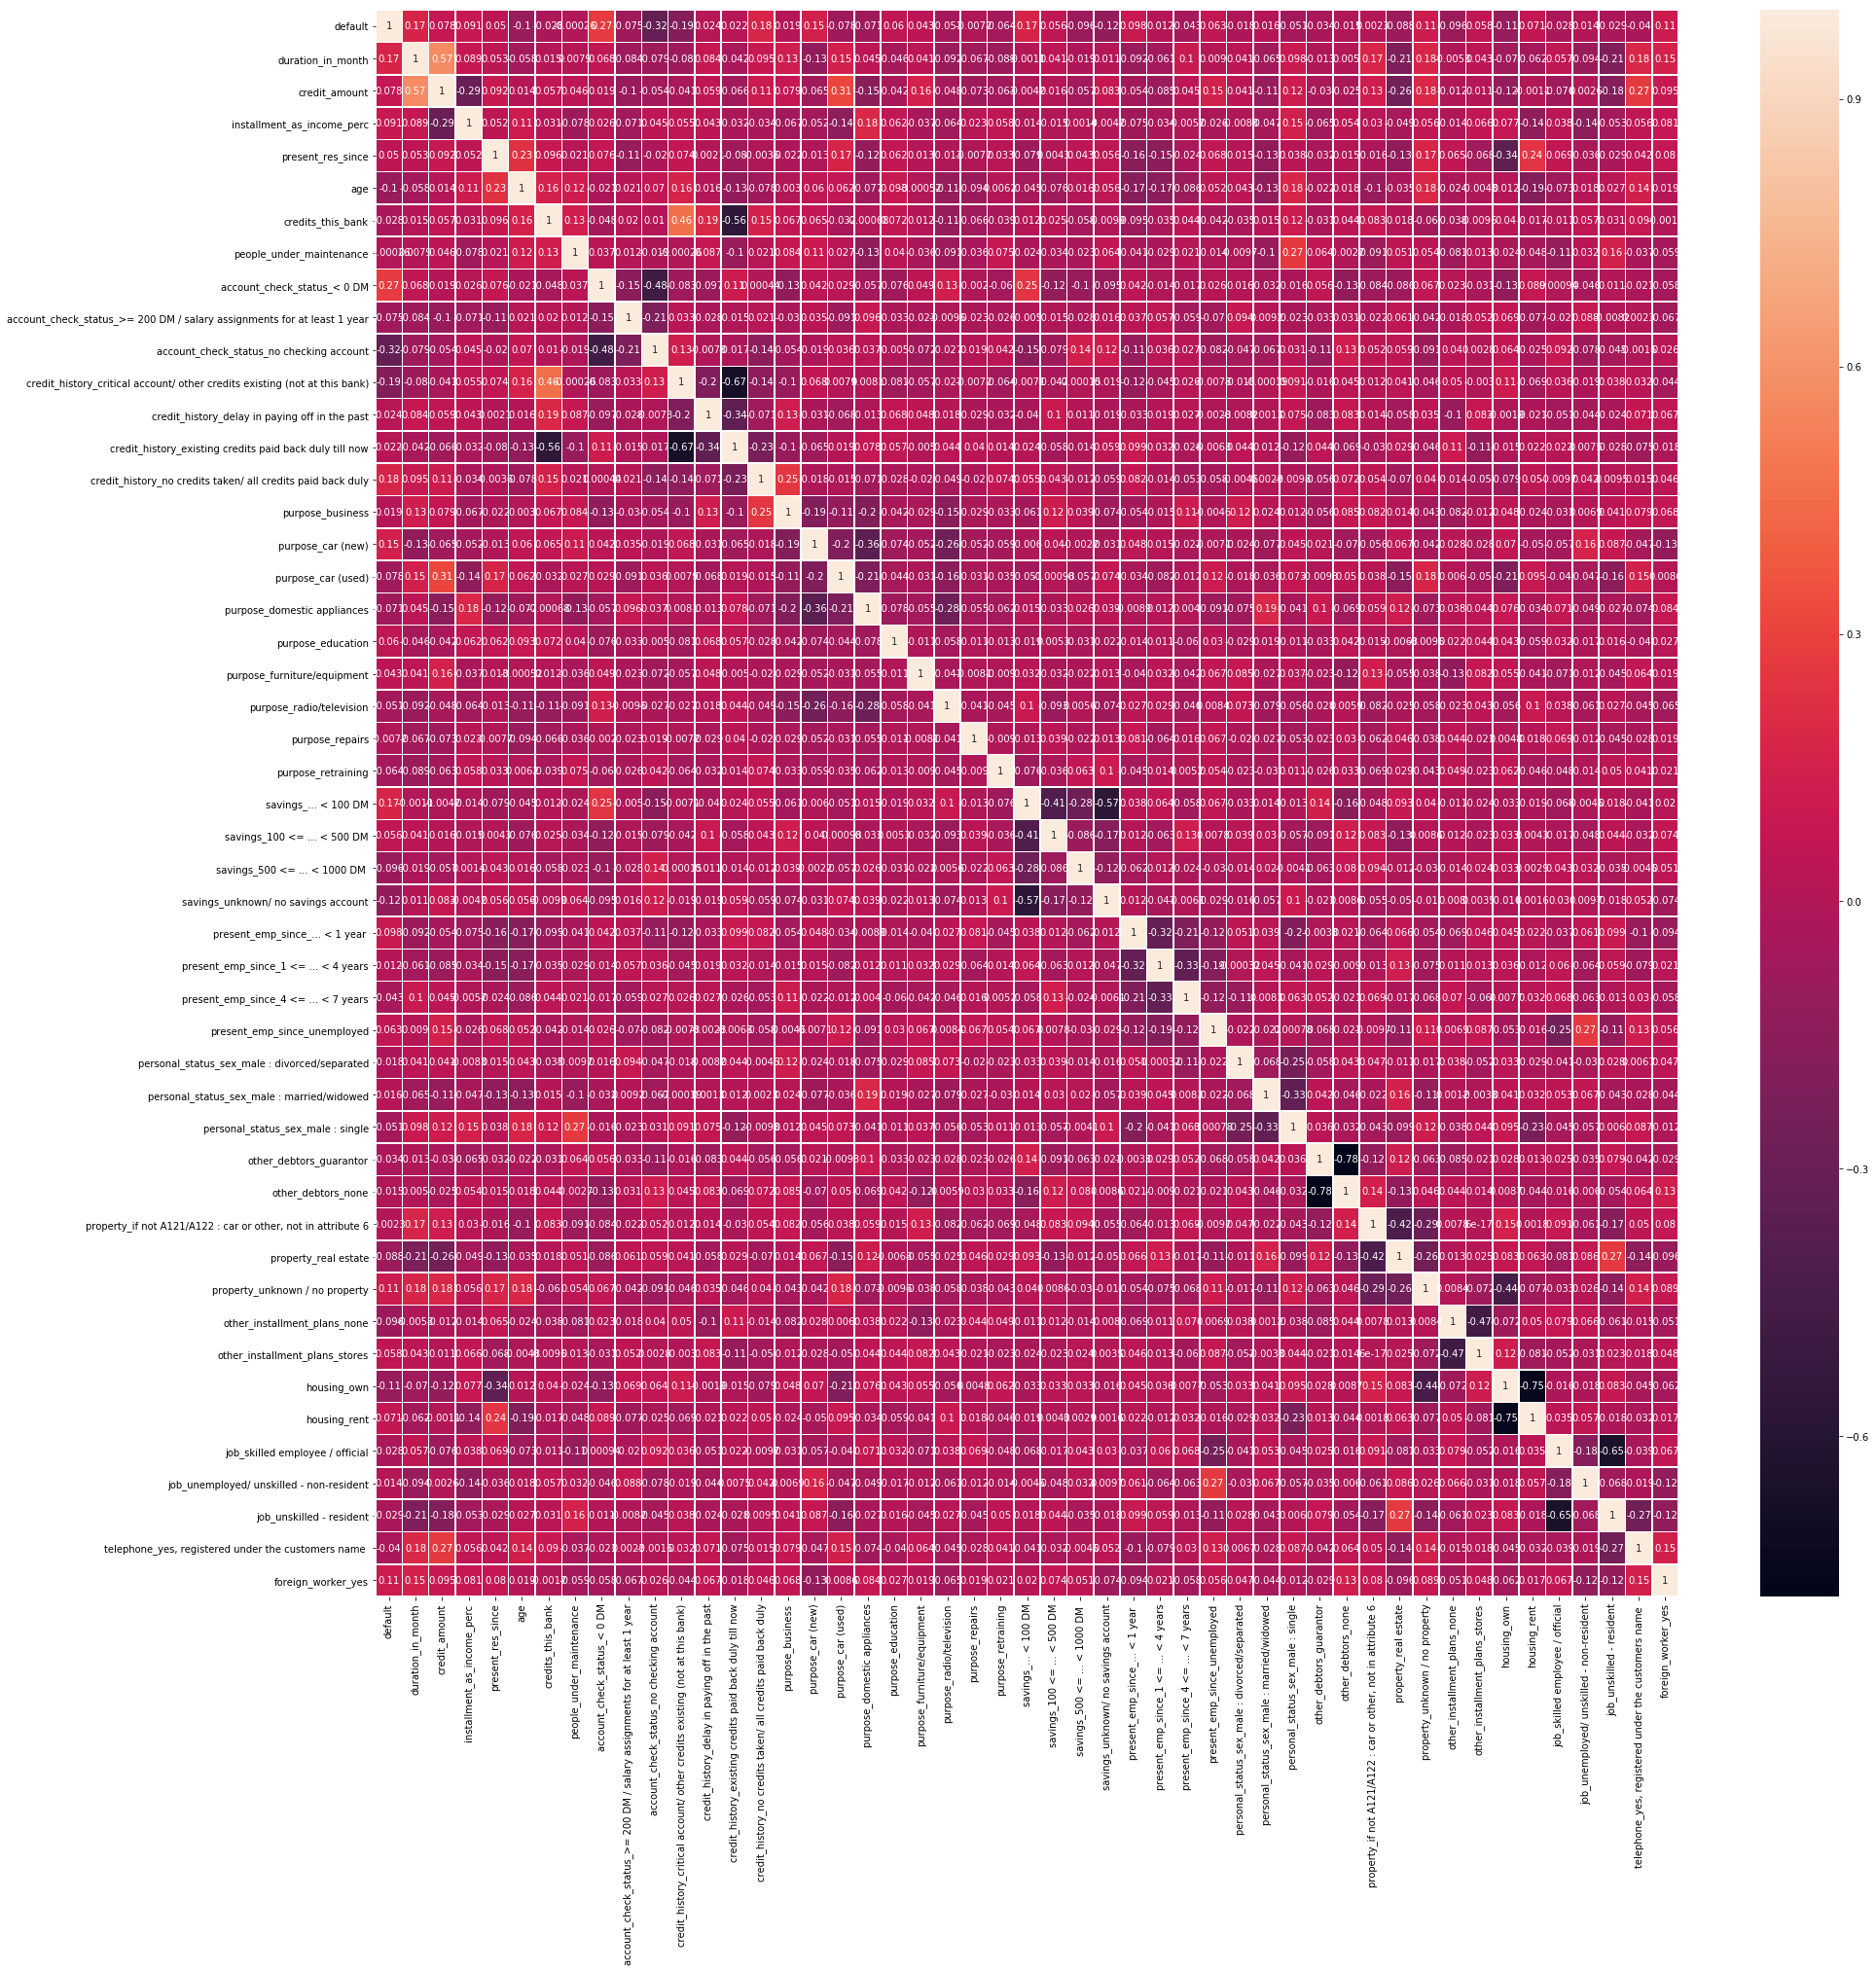

In [102]:
fig, ax = plt.subplots(figsize=(30,30))         # Sample figsize in inches
sns.heatmap(corr_data, annot=True, linewidths=.5, ax=ax)

### Drop the original variables which are converted to dummy

In [103]:
#The orginal variable is already dropped using get_dummies drop_first option

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [104]:
X = data_df.drop("default", axis=1)
y = data_df["default"]

In [123]:
X.shape

(500, 48)

In [124]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [147]:
model = RandomForestClassifier(n_jobs=2, n_estimators=500,criterion='entropy',random_state=seed)
model.fit(X_train, y_train)
ypred = model.predict(X_test)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [148]:
metrics.confusion_matrix(ypred, y_test)

array([[106,  30],
       [  4,  10]], dtype=int64)

In [149]:
acc = metrics.accuracy_score(y_test,ypred)
print("Accuracy =",acc)

Accuracy = 0.7733333333333333


### Q6 Show the list of the features importance( 1 Marks)

In [150]:
feature_list= X.columns

In [151]:
for feature in zip(feature_list, model.feature_importances_):
    print(feature)

('duration_in_month', 0.0860136298021851)
('credit_amount', 0.105831489895928)
('installment_as_income_perc', 0.038785234896619385)
('present_res_since', 0.03929524072311581)
('age', 0.09775246022030297)
('credits_this_bank', 0.021912386499396332)
('people_under_maintenance', 0.011839798240755556)
('account_check_status_< 0 DM', 0.02868027558972558)
('account_check_status_>= 200 DM / salary assignments for at least 1 year', 0.009279718758985749)
('account_check_status_no checking account', 0.052962698834819515)
('credit_history_critical account/ other credits existing (not at this bank)', 0.025393902434087776)
('credit_history_delay in paying off in the past', 0.011078801640360295)
('credit_history_existing credits paid back duly till now', 0.01618620013944598)
('credit_history_no credits taken/ all credits paid back duly', 0.017700619343661277)
('purpose_business', 0.012548074049540461)
('purpose_car (new)', 0.02025442794149689)
('purpose_car (used)', 0.010245741020011774)
('purpose_d

In [154]:
# Create a selector object that will use the random forest classifier to identify
# features that have an importance of more than 0.02
sfm = SelectFromModel(model, threshold=0.02)

# Train the selector
sfm.fit(X_train, y_train)

SelectFromModel(estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=77, verbose=0, warm_start=False),
        max_features=None, norm_order=1, prefit=False, threshold=0.02)

In [155]:
# Print the names of the most important features
for feature_list_index in sfm.get_support(indices=True):
    print(feature_list[feature_list_index])

duration_in_month
credit_amount
installment_as_income_perc
present_res_since
age
credits_this_bank
account_check_status_< 0 DM
account_check_status_no checking account
credit_history_critical account/ other credits existing (not at this bank)
purpose_car (new)
savings_... < 100 DM
other_installment_plans_none
housing_own
job_skilled employee / official


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [156]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [157]:
# Use below values
num_folds = 10
seed = 77

In [158]:
#Validate the Random Forest model build above using k fold

In [159]:
kf=KFold(n_splits=num_folds, random_state=seed)
rmse = []
accuracy=[]
for train,test in kf.split(X,y):
    Xtrain,Xtest=X.iloc[train,:],X.iloc[test,:]
    Ytrain,Ytest=y.iloc[train],y.iloc[test]
    model.fit(Xtrain,Ytrain)
    Y_predict=model.predict(Xtest)
    rmse.append(np.sqrt(metrics.mean_squared_error(Ytest,Y_predict)))
    accuracy.append(metrics.accuracy_score(Ytest,Y_predict))

In [160]:
#Calculate Mean score
print("Cross_Validated_Rmse_mean_score: %0.03f" % (np.mean(rmse)))  
print("Cross_Validated_Accuracy_mean_score: %0.03f" % (np.mean(accuracy)))  

Cross_Validated_Rmse_mean_score: 0.496
Cross_Validated_Accuracy_mean_score: 0.750


In [161]:
# Calculate score standard deviation using std()
print("Cross_Validated Standard-Deviation of accuracy_score: %0.03f" % (np.std(accuracy)))  

Cross_Validated Standard-Deviation of accuracy_score: 0.061


# Q8 Print the confusion matrix( 1 Marks)

In [162]:
# Use cross_val_predict for a summarized predirection. 
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
y_pred_cvp = cross_val_predict(model, X, y, cv=num_folds)

# Print the confusion matrix 
conf_mat = confusion_matrix(y, y_pred_cvp)
conf_mat

array([[334,  23],
       [ 99,  44]], dtype=int64)

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [163]:
recall_cvp = metrics.recall_score(y,y_pred_cvp)
precision_cvp = metrics.precision_score(y,y_pred_cvp)
f1score_cvp = metrics.f1_score(y,y_pred_cvp)

print("Cross_Validated recall_score: %0.03f" % (recall_cvp))  
print("Cross_Validated precision_score: %0.03f" % (precision_cvp))  
print("Cross_Validated f1_score: %0.03f" % (f1score_cvp))  

Cross_Validated recall_score: 0.308
Cross_Validated precision_score: 0.657
Cross_Validated f1_score: 0.419


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [164]:
#Hint: Use roc_curve

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

In [165]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y, y_pred_cvp)

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [166]:
roc_auc = auc(fpr, tpr)
roc_auc

0.6216332686920922

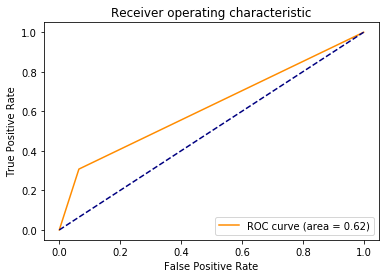

In [167]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [168]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    model.fit(X_, y_)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [ ]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Average: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())